# LCDM - Inspect emulators results

In [1]:
model = 'lcdm'

root = '/ceph/hpc/data/s25r06-05-users/{}'.format(model)

dataset_ranges = ['thin', 'std', 'ext']

## Init

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from tabulate import tabulate
import emu_like.io as io
from emu_like.ffnn_emu import FFNNEmu

2025-11-10 11:16:00.626090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762769760.644463  801202 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762769760.650078  801202 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762769760.664647  801202 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762769760.664660  801202 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762769760.664662  801202 computation_placer.cc:177] computation placer alr

In [3]:
class EmuData(object):

    def __init__(self, path_emu, root=root):
        self.name = path_emu
        self.emu = FFNNEmu()
        self.emu.load(os.path.join(root, path_emu), still_training=False)
        self.abs_diff = None
        self.rel_diff = None
        self.mean_abs_diff = None
        self.mean_rel_diff = None
        pass

    def _scale_x(self, x):
        return self.emu.x_scaler.transform(x)

    def _scale_y(self, y):
        return self.emu.y_scaler.transform(y)

    def _inverse_scale_x(self, x):
        return self.emu.x_scaler.inverse_transform(x)

    def _inverse_scale_y(self, y):
        return self.emu.y_scaler.inverse_transform(y)

    def _pca_x(self, x):
        return self.emu.x_pca.transform(x)

    def _pca_y(self, y):
        return self.emu.y_pca.transform(y)

    def _inverse_pca_x(self, x):
        return self.emu.x_pca.inverse_transform(x)

    def _inverse_pca_y(self, y):
        return self.emu.y_pca.inverse_transform(y)

    def get_y_emu(self, x, want_scaling=False, want_pca=False, select_pca_modes=None, timeit=False):
        """
        From the emulator we get y that are potentially scaled and PCA
        applied. However, it is possible that just one or none of them
        are used. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        if timeit:
            start_all = time.time()

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        n_samples = x.shape[0]

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot keep scaled units: y is already unscaled.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        # 1) Adjust x
        # Adjust dimensions x array
        if x.ndim == 1:
            x = x[np.newaxis, :]
        # Scale x
        if self.emu.x_scaler is not None:
            x = self._scale_x(x)
        # PCA x
        if self.emu.x_pca is not None:
            x = self._pca_x(x)

        # 2) Emulate y
        if timeit:
            start_emu = time.time()
        result = self.emu.model(x, training=False).numpy()
        if timeit:
            stop_emu = time.time()

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if has_pca and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove scaling
        if has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        if timeit:
            stop_all = time.time()
        
        if timeit:
            self.time_emu = (stop_emu-start_emu)/n_samples
            self.time_all = (stop_all-start_all)/n_samples

        return result

    def get_y_data(self, y, want_scaling=False, want_pca=False, select_pca_modes=None):
        """
        Postprocess the data to add/remove scaling and PCA. It works to provide
        a compatible output of get_y_emu. Input data are assumed to not be scaled and
        without PCA applied. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot use scaled units: emulator has no scaling transform.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        result = y

        # 1) Scale
        if want_scaling or (want_pca_selection and has_scaling):
            result = self._scale_y(result)

        # 2) PCA
        if want_pca or want_pca_selection:
            result = self._pca_y(result)

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if want_pca_selection and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove Scale
        if want_pca_selection and has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        return result

    def get_abs_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        """
        Get the absolute difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu,
            timeit= time_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.abs_diff = y_emu - y_data
        return self.abs_diff
    
    def get_rel_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        """
        Get the relative difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu,
            timeit= time_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.rel_diff = y_emu/y_data -1.
        return self.rel_diff

    def get_mean_abs_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        if x_emu is not None and y_data is not None:
            self.abs_diff = self.get_abs_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data,
                time_emu=time_emu)

        self.mean_abs_diff = np.sqrt(np.mean(self.abs_diff**2., axis=1))
        return self.mean_abs_diff
    
    def get_mean_rel_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        if x_emu is not None and y_data is not None:
            self.rel_diff = self.get_rel_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data,
                time_emu=time_emu)

        self.mean_rel_diff = np.sqrt(np.mean(self.rel_diff**2., axis=1))
        return self.mean_rel_diff

    def get_sorting_idxs_abs(self):
        if self.mean_abs_diff is None:
            raise Exception('Calculate mean_abs_diff first')
        return self.mean_abs_diff.argsort()[::-1]

    def get_sorting_idxs_rel(self):
        if self.mean_rel_diff is None:
            raise Exception('Calculate mean_rel_diff first')
        return self.mean_rel_diff.argsort()[::-1]

In [4]:
def show_summary(spectra, dataset_ranges=dataset_ranges, vlines=[0.01, 0.05, 0.1, 1.]):
    # Create figure
    fig, axs = plt.subplots(len(spectra), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(spectra)), squeeze=False, sharex=False)

    # Init table
    headers = ['name']
    headers += ['>{}%'.format(val) for val in vlines]
    headers += ['Time emu (s)', 'Time get_y_emu (s)']
    headers += ['Epochs (best/tot)', 'Loss', 'Val Loss', 'Learning rate']
    tab = []

    emudata = {}

    # Plot data in each subplot
    for nspectrum, (spectrum, spectrum_type, diff) in enumerate(spectra):
        emudata[spectrum] = {}
        
        for ndr, dr in enumerate(dataset_ranges):

            # Load emulator
            try:
                emudata[spectrum][dr] = EmuData(spectrum, root=os.path.join(root, 'train'))
            except ValueError:
                emudata[spectrum][dr] = None
                continue

            # Get best epoch
            epochs = emudata[spectrum][dr].emu.epochs
            losses = emudata[spectrum][dr].emu.loss
            val_losses = emudata[spectrum][dr].emu.val_loss
            learning_rates = emudata[spectrum][dr].emu.learning_rate

            idx_best = np.where(val_losses == np.min(val_losses))[0][0]

            # Rel or abs diff
            if diff == 'rel':
                fun = emudata[spectrum][dr].get_mean_rel_diff
            elif diff == 'abs':
                fun = emudata[spectrum][dr].get_mean_abs_diff
            else:
                raise ValueError('Difference type not recognized!')

            # Load data
            path_dataset = os.path.join(root, 'sample/{}_100_{}.fits'.format(spectrum_type, dr))
            dataset = io.FitsFile(path_dataset)
            x_data = dataset.get_data('x_data')
            y_data = dataset.get_data(spectrum)

            result = fun(
                x_emu=x_data,
                y_data=y_data,
                want_scaling=False,
                want_pca=False,
                select_pca_modes_emu=None,
                select_pca_modes_data=None,
                time_emu=True)

            # Table
            if ndr == 0:
                tab.append(['{}'.format(spectrum)] + (len(vlines)+2)*[''])
            tab_line = ['---> {}'.format(dr)]
            tab_line += ['{:.3f}%'.format(len(result[result>val/100.])/len(result)*100.)
                        for val in vlines]
            tab_line += ['{:.1e}'.format(emudata[spectrum][dr].time_emu)]
            tab_line += ['{:.1e}'.format(emudata[spectrum][dr].time_all)]        
            tab_line += ['{}/{}'.format(int(epochs[idx_best]), int(epochs[-1]))]        
            tab_line += ['{:.2e}'.format(losses[idx_best])]
            tab_line += ['{:.2e}'.format(val_losses[idx_best])]
            tab_line += ['{:.2e}'.format(learning_rates[idx_best])]
            tab.append(tab_line)

            # Figure

            axs[nspectrum, ndr].hist(np.log10(result), log=True, bins=20)
            axs[nspectrum, ndr].set_title('{} - {}'.format(spectrum, dr), fontsize=18)
            axs[nspectrum, ndr].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)
            for val in vlines:
                if diff == 'abs':
                    maxy = np.max(np.abs(y_data))
                else:
                    maxy = 1.
                axs[nspectrum, ndr].axvline(x=np.log10(maxy*val/100.), c='r')
                emudata[spectrum][dr].max_y_data = maxy

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print table
    print(tabulate(tab, headers=headers, tablefmt='orgtbl'))

    return emudata


In [5]:
def plot_worst_modes(spectra, emudata, n_modes_kept=3, vlines=[0.01, 0.05, 0.1, 1.]):
    fig, axs = plt.subplots(len(spectra), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(spectra)), squeeze=False, sharex=False)
    fig.suptitle('Worst modes', fontsize=30, y=1.0)

    for nspectrum, (spectrum, _, diff_rel_abs) in enumerate(spectra):
        for ndr, dr in enumerate(dataset_ranges):

            if emudata[spectrum][dr] is None:
                continue

            # Rel or abs diff
            if diff_rel_abs == 'rel':
                idxs = emudata[spectrum][dr].get_sorting_idxs_rel()[:n_modes_kept]
                diffs = emudata[spectrum][dr].rel_diff[idxs]
            elif diff_rel_abs == 'abs':
                idxs = emudata[spectrum][dr].get_sorting_idxs_abs()[:n_modes_kept]
                diffs = emudata[spectrum][dr].abs_diff[idxs]
            else:
                raise ValueError('Difference type not recognized!')


            for val in vlines:
                axs[nspectrum, ndr].axhline(
                    emudata[spectrum][dr].max_y_data*val, c='k', lw=0.1)

            for ndiff, diff in enumerate(diffs):
                axs[nspectrum, ndr].plot(np.abs(diff)*100., label='rank: {}, idx: {}'.format(ndiff+1, idxs[ndiff]))
                axs[nspectrum, ndr].set_yscale('log')
                axs[nspectrum, ndr].set_title('{} - {}'.format(spectrum, dr), fontsize=18)
            if diff_rel_abs == 'rel':
                axs[nspectrum, 0].set_ylabel('rel diff [%]')
            elif diff_rel_abs == 'abs':
                axs[nspectrum, 0].set_ylabel('abs diff')

            axs[nspectrum, ndr].legend()

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()

    return


## Histograms

In [6]:
spectra = [
    ('pk_m',         'pk', 'rel'),
    ('pk_cb',        'pk', 'rel'),
    ('pk_weyl',      'pk', 'rel'),
    ('fk_m',         'pk', 'rel'),
    ('fk_cb',        'pk', 'rel'),
    ('fk_weyl',      'pk', 'rel'),
    ('cl_TT_lensed', 'cl', 'rel'),
    ('cl_TE_lensed', 'cl', 'abs'),
    ('cl_EE_lensed', 'cl', 'rel'),
    ('cl_BB_lensed', 'cl', 'rel'),
    ('cl_Tp_lensed', 'cl', 'abs'),
    ('cl_pp_lensed', 'cl', 'rel'),
]

W0000 00:00:1762769765.586184  801202 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-11-10 11:16:09.308304: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-11-10 11:16:09.355832: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-11-10 11:16:09.406937: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-11-10 11:16:09.449045: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2025-11-10 11:16:09.52432

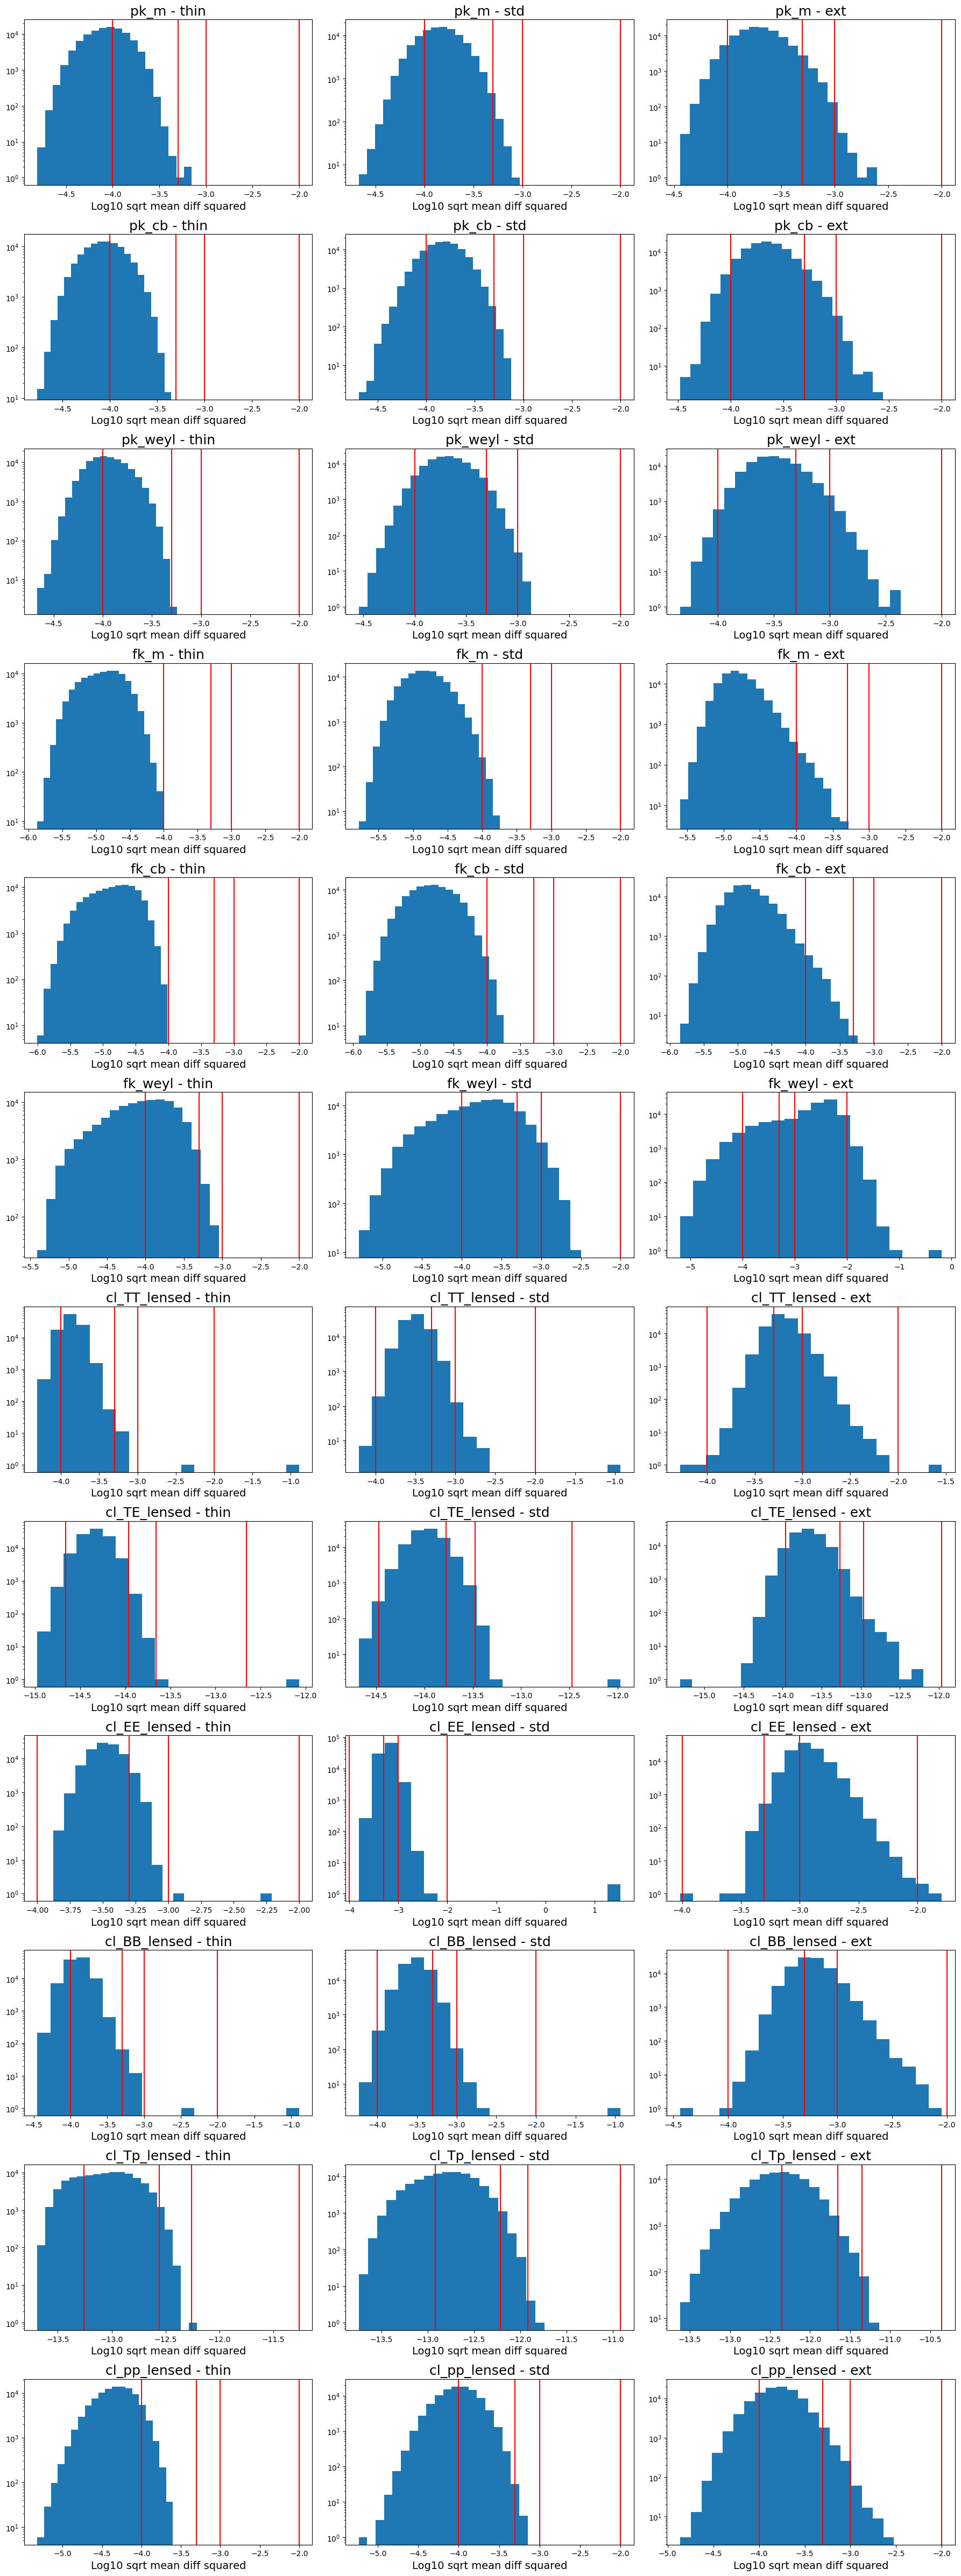

| name         | >0.01%   | >0.05%   | >0.1%   | >1.0%   | Time emu (s)   | Time get_y_emu (s)   | Epochs (best/tot)   |     Loss |   Val Loss |   Learning rate |
|--------------+----------+----------+---------+---------+----------------+----------------------+---------------------+----------+------------+-----------------|
| pk_m         |          |          |         |         |                |                      |                     |          |            |                 |
| ---> thin    | 39.985%  | 0.003%   | 0.000%  | 0.000%  | 4.4e-06        | 3.7e-05              | 12681/14681         | 1.51e-07 |   1.68e-07 |        2.44e-07 |
| ---> std     | 78.294%  | 0.237%   | 0.000%  | 0.000%  | 3.8e-06        | 2.5e-05              | 12681/14681         | 1.51e-07 |   1.68e-07 |        2.44e-07 |
| ---> ext     | 92.883%  | 3.157%   | 0.047%  | 0.000%  | 3.8e-06        | 2.5e-05              | 12681/14681         | 1.51e-07 |   1.68e-07 |        2.44e-07 |
| pk_cb        |      

In [7]:
emudata = show_summary(spectra)

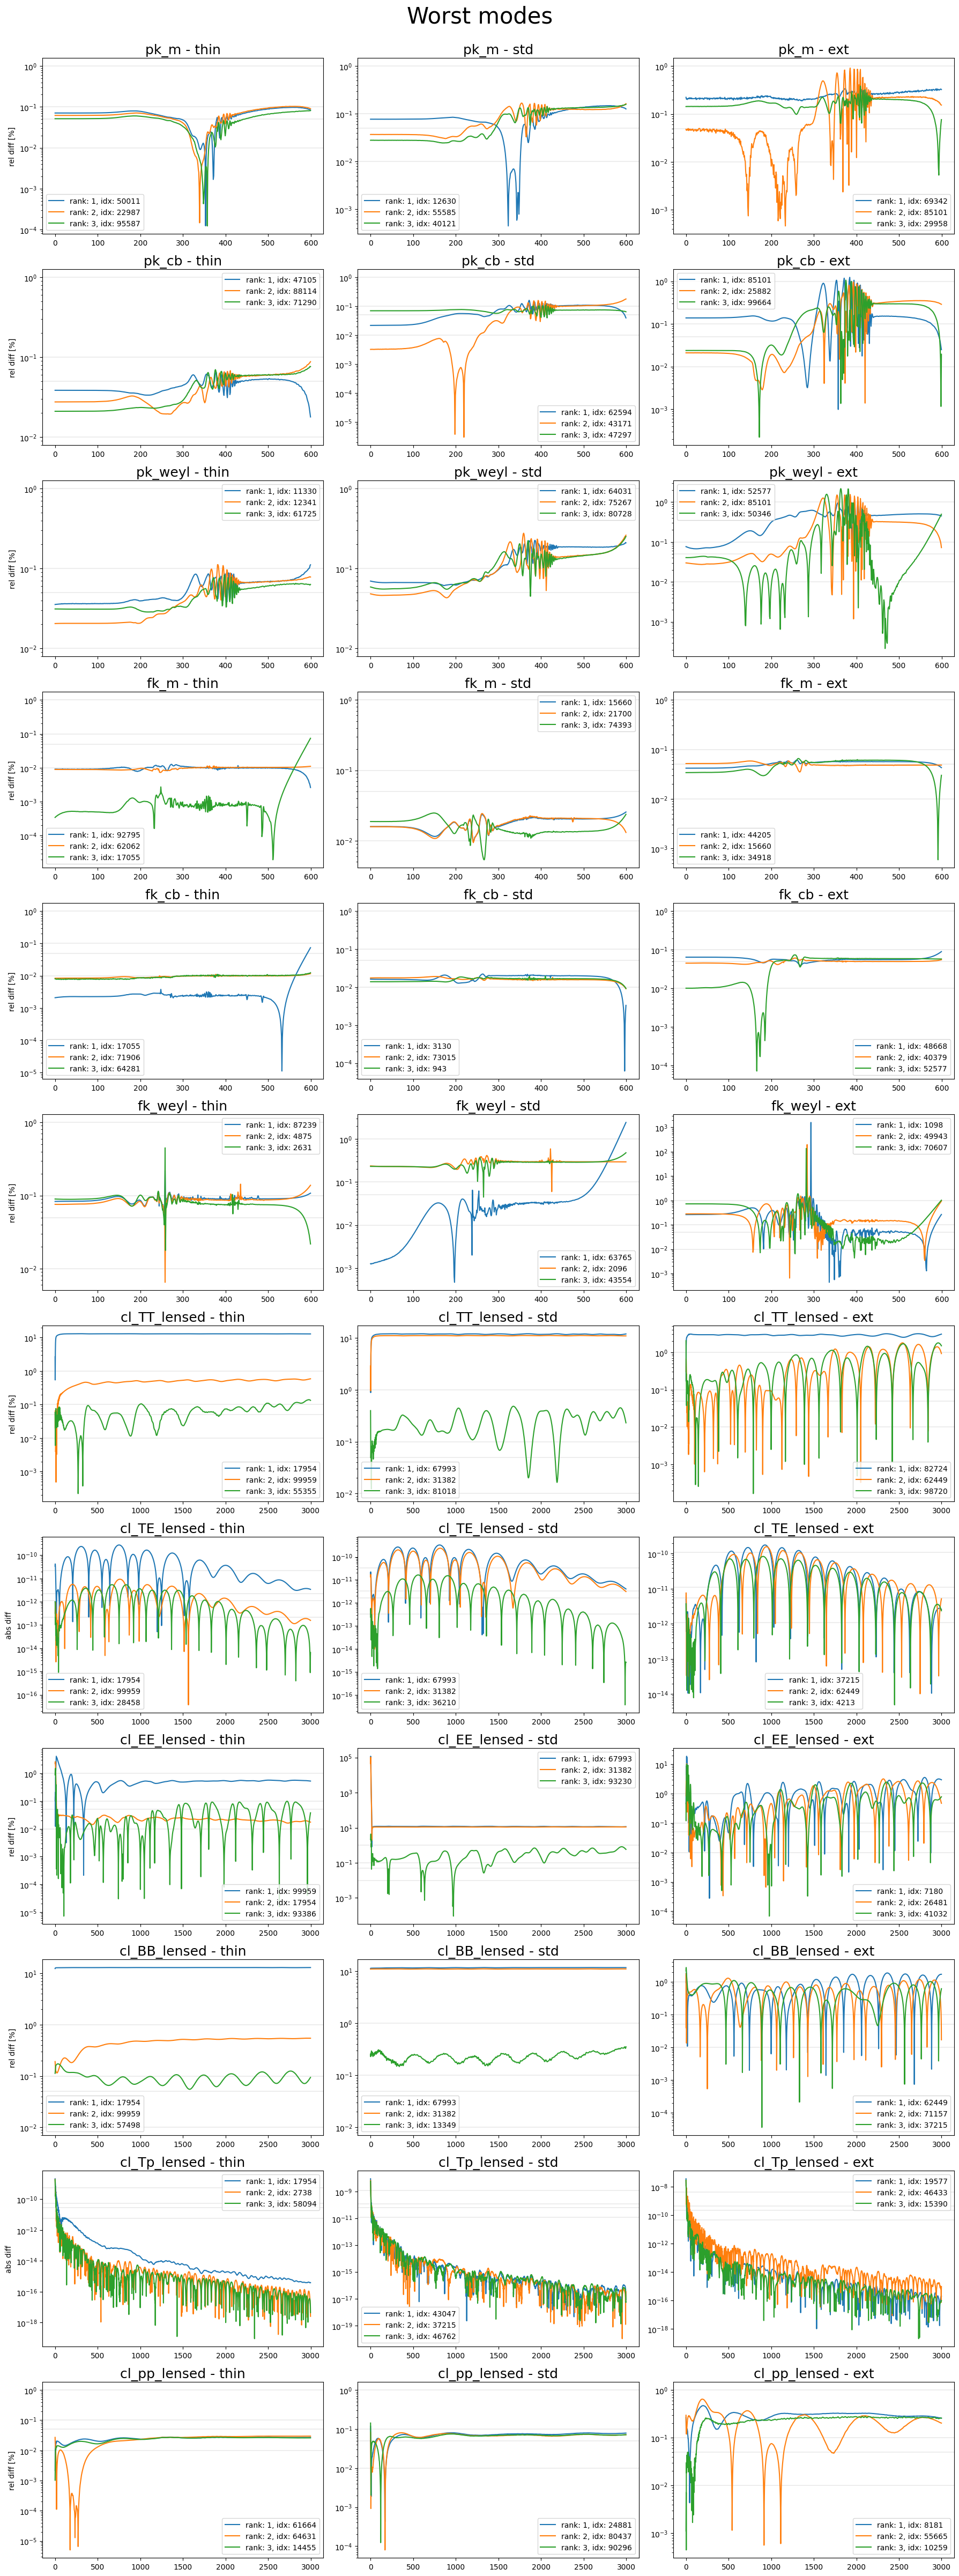

In [8]:
plot_worst_modes(spectra, emudata, n_modes_kept=3)